In [6]:
# %%
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dask_ml.preprocessing import Categorizer
from glum import GeneralizedLinearRegressor, TweedieDistribution
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.metrics import auc
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler

from ps3.data import create_sample_split, load_transform

In [7]:
# %%
# load data
df = load_transform()
df.head()

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmount,ClaimAmountCut
0,1,0,0.10,D,5,0,5,50,B12,Regular,1217,R82,0.0,0.0
1,3,0,0.77,D,5,0,5,50,B12,Regular,1217,R82,0.0,0.0
2,5,0,0.75,B,6,1,5,50,B12,Diesel,54,R22,0.0,0.0
3,10,0,0.09,B,7,0,4,50,B12,Diesel,76,R72,0.0,0.0
4,11,0,0.84,B,7,0,4,50,B12,Diesel,76,R72,0.0,0.0


In [9]:
# Train benchmark tweedie model. This is entirely based on the glum tutorial.
weight = df["Exposure"].values
df["PurePremium"] = df["ClaimAmountCut"] / df["Exposure"]
y = df["PurePremium"]
# TODO: Why do you think, we divide by exposure here to arrive at
# our outcome variable?
# Because we would be looking at policies with different active durations.
# One person could have a policy of 16 years, and one for 8.
# The claim amounts would be different because the timespan is different.
# We compare risk fairly

df = create_sample_split(df, 'IDpol')
train = np.where(df["sample"] == "train")
test = np.where(df["sample"] == "test")
df_train = df.iloc[train].copy()
df_test = df.iloc[test].copy()

categoricals = ["VehBrand", "VehGas", "Region", "Area",
                "DrivAge", "VehAge", "VehPower"]

predictors = categoricals + ["BonusMalus", "Density"]
glm_categorizer = Categorizer(columns=categoricals)

X_train_t = glm_categorizer.fit_transform(df[predictors].iloc[train])
X_test_t = glm_categorizer.transform(df[predictors].iloc[test])
y_train_t, y_test_t = y.iloc[train], y.iloc[test]
w_train_t, w_test_t = weight[train], weight[test]

TweedieDist = TweedieDistribution(1.5)
t_glm1 = GeneralizedLinearRegressor(family=TweedieDist, l1_ratio=1,
                                    fit_intercept=True)
t_glm1.fit(X_train_t, y_train_t, sample_weight=w_train_t)


pd.DataFrame(
    {"coefficient": np.concatenate(([t_glm1.intercept_], t_glm1.coef_))},
    index=["intercept"] + t_glm1.feature_names_,
).T

df_test["pp_t_glm1"] = t_glm1.predict(X_test_t)
df_train["pp_t_glm1"] = t_glm1.predict(X_train_t)

print(
    "training loss t_glm1:  {}".format(
        TweedieDist.deviance(y_train_t, df_train["pp_t_glm1"],
                             sample_weight=w_train_t)
        / np.sum(w_train_t)
    )
)

print(
    "testing loss t_glm1:  {}".format(
        TweedieDist.deviance(y_test_t, df_test["pp_t_glm1"],
                             sample_weight=w_test_t)
        / np.sum(w_test_t)
    )
)

print(
    "Total claim amount on test set, observed = {}, predicted = {}".format(
        df["ClaimAmountCut"].values[test].sum(),
        np.sum(df["Exposure"].values[test] * t_glm1.predict(X_test_t)),
    )
)
# %%
# TODO: Let's add splines for BonusMalus and Density and use a Pipeline.
# Steps:
# 1. Define a Pipeline which chains a StandardScaler and SplineTransformer.
#    Choose knots="quantile" for the SplineTransformer and make sure, we
#    are only including one intercept in the final GLM.
# 2. Put the transforms together into a ColumnTransformer.
# Here we use OneHotEncoder for the categoricals.
# 3. Chain the transforms together with the GLM in a Pipeline.

# Let's put together a pipeline
numeric_cols = ["BonusMalus", "Density"]
numeric_pipeline = Pipeline(
    steps=[
        ("scale", StandardScaler()),
        (
            "splines",
            SplineTransformer(
                degree=3,
                n_knots=5,
                knots="quantile",
                include_bias=False,
            ),
        ),
    ],
)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        (
            "cat",
            OneHotEncoder(
                sparse_output=False,
                drop="first",
                handle_unknown="ignore",
            ),
            categoricals,
        ),
    ]
)
preprocessor.set_output(transform="pandas")
model_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "estimate",
            GeneralizedLinearRegressor(
                family=TweedieDist,
                fit_intercept=True,
                l1_ratio=1,
            ),
        ),
    ]
)

# let's have a look at the pipeline
model_pipeline

# let's check that the transforms worked
model_pipeline[:-1].fit_transform(df_train)

model_pipeline.fit(df_train, y_train_t, estimate__sample_weight=w_train_t)

pd.DataFrame(
    {
        "coefficient": np.concatenate(
            ([model_pipeline[-1].intercept_], model_pipeline[-1].coef_)
        )
    },
    index=["intercept"] + model_pipeline[-1].feature_names_,
).T

df_test["pp_t_glm2"] = model_pipeline.predict(df_test)
df_train["pp_t_glm2"] = model_pipeline.predict(df_train)

print(
    "training loss t_glm2:  {}".format(
        TweedieDist.deviance(y_train_t, df_train["pp_t_glm2"],
                             sample_weight=w_train_t)
        / np.sum(w_train_t)
    )
)

print(
    "testing loss t_glm2:  {}".format(
        TweedieDist.deviance(y_test_t, df_test["pp_t_glm2"],
                             sample_weight=w_test_t)
        / np.sum(w_test_t)
    )
)

print(
    "Total claim amount on test set, observed = {}, predicted = {}".format(
        df["ClaimAmountCut"].values[test].sum(),
        np.sum(df["Exposure"].values[test] * df_test["pp_t_glm2"]),
    )
)

training loss t_glm1:  74.09624367237065
testing loss t_glm1:  72.41964708673862
Total claim amount on test set, observed = 9640879.090000004, predicted = 10021805.61500875


/opt/miniconda3/envs/ps3/lib/python3.12/site-packages/glum/_solvers.py:59: ConvergenceWarning: Coordinate descent did not converge. You might want to increase the number of iterations. Minimum norm subgradient: 0.000958105753660929, tolerance: 0.0001
  new_coef, gap, _, _, n_cycles = enet_coordinate_descent_gram(
/opt/miniconda3/envs/ps3/lib/python3.12/site-packages/glum/_solvers.py:59: ConvergenceWarning: Coordinate descent did not converge. You might want to increase the number of iterations. Minimum norm subgradient: 0.0007394173509338705, tolerance: 0.0001
  new_coef, gap, _, _, n_cycles = enet_coordinate_descent_gram(
/opt/miniconda3/envs/ps3/lib/python3.12/site-packages/glum/_solvers.py:59: ConvergenceWarning: Coordinate descent did not converge. You might want to increase the number of iterations. Minimum norm subgradient: 0.00056977123129452, tolerance: 0.0001
  new_coef, gap, _, _, n_cycles = enet_coordinate_descent_gram(
/opt/miniconda3/envs/ps3/lib/python3.12/site-packages/g

training loss t_glm2:  73.70597588340354
testing loss t_glm2:  72.25229123372912
Total claim amount on test set, observed = 9640879.090000004, predicted = 9999830.105207022


In [10]:
model_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "estimate",
            LGBMRegressor(
                objective="tweedie",
                tweedie_variance_power=1.5,
                n_estimators=500,
                learning_rate=0.05,
                num_leaves=31,
                min_data_in_leaf=200,
                subsample=0.8,
                colsample_bytree=0.8,
            ),
        ),
    ]
)
model_pipeline.fit(X_train_t, y_train_t, estimate__sample_weight=w_train_t)
df_test["pp_t_lgbm"] = model_pipeline.predict(X_test_t)
df_train["pp_t_lgbm"] = model_pipeline.predict(X_train_t)
print(
    "training loss t_lgbm:  {}".format(
        TweedieDist.deviance(y_train_t, df_train["pp_t_lgbm"],
                             sample_weight=w_train_t)
        / np.sum(w_train_t)
    )
)

print(
    "testing loss t_lgbm:  {}".format(
        TweedieDist.deviance(y_test_t, df_test["pp_t_lgbm"],
                             sample_weight=w_test_t)
        / np.sum(w_test_t)
    )
)

[LightGBM] [Warning] min_data_in_leaf is set=200, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=200
[LightGBM] [Warning] min_data_in_leaf is set=200, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=200
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006783 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1725
[LightGBM] [Info] Number of data points in the train set: 541985, number of used features: 60
[LightGBM] [Info] Start training from score 4.930492
[LightGBM] [Warning] min_data_in_leaf is set=200, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=200
[LightGBM] [Warning] min_data_in_leaf is set=200, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=200
training loss t_lgbm:  62.33668412173234
testing loss t_lgbm:  72.46068407937433


Fitting 3 folds for each of 9 candidates, totalling 27 fits
[LightGBM] [Warning] min_data_in_leaf is set=200, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=200
[LightGBM] [Warning] min_data_in_leaf is set=200, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=200
[LightGBM] [Warning] min_data_in_leaf is set=200, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=200
[LightGBM] [Warning] min_data_in_leaf is set=200, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=200
[LightGBM] [Warning] min_data_in_leaf is set=200, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=200
[LightGBM] [Warning] min_data_in_leaf is set=200, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=200
[LightGBM] [Warning] min_data_in_leaf is set=200, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=200
[LightGBM] [Warning] min_data_in_leaf is set=200, min_child_samples=20 w

[]

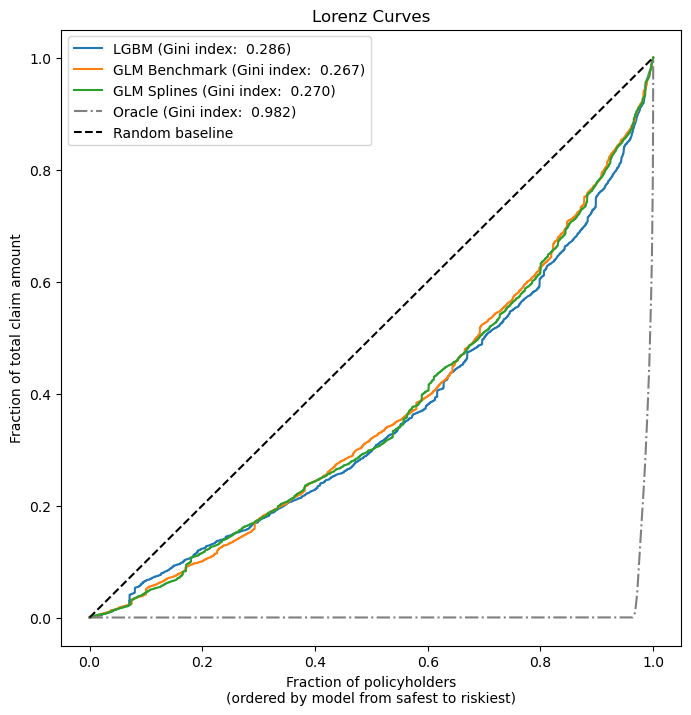

In [12]:
param_grid = {
    "estimate__learning_rate": [0.1, 0.05, 0.01],
    "estimate__n_estimators": [300, 500, 1000],
}

cv = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_poisson_deviance",
    cv=3,
    n_jobs=-1,
    verbose=1,
)
cv.fit(X_train_t, y_train_t, estimate__sample_weight=w_train_t)

df_test["pp_t_lgbm"] = cv.best_estimator_.predict(X_test_t)
df_train["pp_t_lgbm"] = cv.best_estimator_.predict(X_train_t)

print(
    "training loss t_lgbm:  {}".format(
        TweedieDist.deviance(y_train_t, df_train["pp_t_lgbm"],
                             sample_weight=w_train_t)
        / np.sum(w_train_t)
    )
)

print(
    "testing loss t_lgbm:  {}".format(
        TweedieDist.deviance(y_test_t, df_test["pp_t_lgbm"], sample_weight=w_test_t)
        / np.sum(w_test_t)
    )
)

print(
    "Total claim amount on test set, observed = {}, predicted = {}".format(
        df["ClaimAmountCut"].values[test].sum(),
        np.sum(df["Exposure"].values[test] * df_test["pp_t_lgbm"]),
    )
)
# %%
# Let's compare the sorting of the pure premium predictions


# Source: https://scikit-learn.org/stable/auto_examples/linear_model
# /plot_tweedie_regression_insurance_claims.html
def lorenz_curve(y_true, y_pred, exposure):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    exposure = np.asarray(exposure)

    # order samples by increasing predicted risk:
    ranking = np.argsort(y_pred)
    ranked_exposure = exposure[ranking]
    ranked_pure_premium = y_true[ranking]
    cumulated_claim_amount = np.cumsum(ranked_pure_premium * ranked_exposure)
    cumulated_claim_amount /= cumulated_claim_amount[-1]
    cumulated_samples = np.linspace(0, 1, len(cumulated_claim_amount))
    return cumulated_samples, cumulated_claim_amount


fig, ax = plt.subplots(figsize=(8, 8))

for label, y_pred in [
    ("LGBM", df_test["pp_t_lgbm"]),
    ("GLM Benchmark", df_test["pp_t_glm1"]),
    ("GLM Splines", df_test["pp_t_glm2"]),
]:
    ordered_samples, cum_claims = lorenz_curve(
        df_test["PurePremium"], y_pred, df_test["Exposure"]
    )
    gini = 1 - 2 * auc(ordered_samples, cum_claims)
    label += f" (Gini index: {gini: .3f})"
    ax.plot(ordered_samples, cum_claims, linestyle="-", label=label)

# Oracle model: y_pred == y_test
ordered_samples, cum_claims = lorenz_curve(
    df_test["PurePremium"], df_test["PurePremium"], df_test["Exposure"]
)
gini = 1 - 2 * auc(ordered_samples, cum_claims)
label = f"Oracle (Gini index: {gini: .3f})"
ax.plot(ordered_samples, cum_claims, linestyle="-.", color="gray", label=label)

# Random baseline
ax.plot([0, 1], [0, 1], linestyle="--", color="black", label="Random baseline")
ax.set(
    title="Lorenz Curves",
    xlabel="Fraction of policyholders\n(ordered by model from safest to riskiest)",
    ylabel="Fraction of total claim amount",
)
ax.legend(loc="upper left")
plt.plot()

# %%


In [13]:
# Access the best parameters found by GridSearchCV
print("Best hyperparameters found by GridSearchCV:")
print(cv.best_params_)


Best hyperparameters found by GridSearchCV:
{'estimate__learning_rate': 0.01, 'estimate__n_estimators': 300}
